<a href="https://colab.research.google.com/github/fayomiEsther82/ML-Learning-Notebooks/blob/main/02_Pandas_DataFrames.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np


The cudf.pandas extension is already loaded. To reload it, use:
  %reload_ext cudf.pandas


In [74]:
data = {
    'Student_Names' : ['Tom', 'Jack', 'Steve', 'Ricky'],
    'Score' : [20, 30, 40, 50],
    'Course' : ['python', 'Pandas', 'NumPy', 'python']
}

df = pd.DataFrame(data)
#print(pd.DataFrame(data))

print("Dataframe created successfully")
print(df)
print('\nType Confirmation:')
print(type(df))

Dataframe created successfully
  Student_Names  Score  Course
0           Tom     20  python
1          Jack     30  Pandas
2         Steve     40   NumPy
3         Ricky     50  python

Type Confirmation:
<class 'pandas.core.frame.DataFrame'>


In [75]:
scores = df['Score']
print("Selected Column(Scores):\n", scores)

Selected Column(Scores):
 0    20
1    30
2    40
3    50
Name: Score, dtype: int64


In [76]:
two_columns = df[['Score', 'Course']]
print("Selected Columns(Scores, Courses):\n", two_columns)

Selected Columns(Scores, Courses):
    Score  Course
0     20  python
1     30  Pandas
2     40   NumPy
3     50  python


In [77]:
high_scorers = df[df['Score'] > 30][['Student_Names', 'Score']]
print("Students with scores greater than 30:\n", high_scorers)

Students with scores greater than 30:
   Student_Names  Score
2         Steve     40
3         Ricky     50


In [78]:
mean_score = df['Score'].mean()
print("Mean Score:", mean_score)

Mean Score: 35.0


In [79]:
score_stats = df['Score'].describe()

print("\nScore Statistics:\n", df)

count = score_stats['count']
mean = score_stats['mean']
std = score_stats['std']
min_score = score_stats['min']
max_score = score_stats['max']

print("Count:", count)
print("Mean:", mean)
print("Standard Deviation:", std)
print("Minimum:", min_score)
print("Maximum:", max_score)


Score Statistics:
   Student_Names  Score  Course
0           Tom     20  python
1          Jack     30  Pandas
2         Steve     40   NumPy
3         Ricky     50  python
Count: 4.0
Mean: 35.0
Standard Deviation: 12.909944487358056
Minimum: 20.0
Maximum: 50.0


In [80]:
average_by_course = df.groupby('Course')['Score'].mean()
print("Average Score by Course:\n", average_by_course)

Average Score by Course:
 Course
NumPy     40.0
Pandas    30.0
python    35.0
Name: Score, dtype: float64


In [81]:
# Introduce a missing value (Replace one score with NaN)
df.loc[0, 'Score'] = np.nan

print("DataFrame with missing value:\n", df)

DataFrame with missing value:
   Student_Names  Score  Course
0           Tom    NaN  python
1          Jack   30.0  Pandas
2         Steve   40.0   NumPy
3         Ricky   50.0  python


In [82]:
# Identify missing values
missing_values = df.isnull()

print("DataFrame showing missing values (True indicates missing):\n", missing_values)

DataFrame showing missing values (True indicates missing):
    Student_Names  Score  Course
0          False   True   False
1          False  False   False
2          False  False   False
3          False  False   False


In [83]:
# Create a new DataFrame, dropping any rows with missing data
df_clean = df.dropna()

print("\nCleaned DataFrame (Missing values removed):\n", df_clean)


Cleaned DataFrame (Missing values removed):
   Student_Names  Score  Course
1          Jack   30.0  Pandas
2         Steve   40.0   NumPy
3         Ricky   50.0  python


In [84]:
average_score = df['Score'].mean()
print("Average Score is", average_score)
maximum_score = df['Score'].max()
print("Maximum Score is", maximum_score)

Average Score is 40.0
Maximum Score is 50.0


In [85]:
df = df.rename(columns = {'Student_Names' : 'Name',
                          'Score' : 'Final_Score_Numeric'})
print("Renamed columns:\n", df)

Renamed columns:
     Name  Final_Score_Numeric  Course
0    Tom                  NaN  python
1   Jack                 30.0  Pandas
2  Steve                 40.0   NumPy
3  Ricky                 50.0  python


In [86]:
print("Initial Data Types:\n", type(df))
print("Initial Data Types:\n", type(df['Name']))
print("Initial Data Types:\n", type(df['Final_Score_Numeric']))
print("Initial Data Types:\n", type(df['Course']))

Initial Data Types:
 <class 'pandas.core.frame.DataFrame'>
Initial Data Types:
 <class 'pandas.core.series.Series'>
Initial Data Types:
 <class 'pandas.core.series.Series'>
Initial Data Types:
 <class 'pandas.core.series.Series'>


In [87]:
# Check the current data types of your columns.
print("Initial Data Types:\n", df.dtypes)

Initial Data Types:
 Name                    object
Final_Score_Numeric    float64
Course                  object
dtype: object


In [88]:
df.loc[0 , 'Final_Score_Numeric'] = 50

In [89]:
# Manually fill the missing value at index 0 in 'Final_Score_Numeric'
df.loc[0, 'Final_Score_Numeric'] = 50

# Convert the 'Final_Score_Numeric' column to integer type
df['Final_Score_Numeric'] = df['Final_Score_Numeric'].astype(int)

print("DataFrame with 'Final_Score_Numeric' column converted to integer:\n", df)
print("\nData types after conversion:\n", df.dtypes)

DataFrame with 'Final_Score_Numeric' column converted to integer:
     Name  Final_Score_Numeric  Course
0    Tom                   50  python
1   Jack                   30  Pandas
2  Steve                   40   NumPy
3  Ricky                   50  python

Data types after conversion:
 Name                   object
Final_Score_Numeric     int64
Course                 object
dtype: object


In [90]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("azeembootwala/titanic")

print("Path to dataset files:", path)

100%|██████████| 12.1k/12.1k [00:00<00:00, 17.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/azeembootwala/titanic/versions/1


In [91]:
from google.colab import drive
import shutil
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# Define the destination path in your Google Drive
# You can change 'Kaggle_Titanic_Dataset' to your desired folder name
drive_destination_path = '/content/drive/My Drive/Kaggle_Titanic_Dataset'

# Create the destination directory if it doesn't exist
os.makedirs(drive_destination_path, exist_ok=True)

# 2. Copy the downloaded dataset files to Google Drive
# The 'path' variable contains the location of the downloaded files from the previous cell
source_path = path # 'path' is from the output of the previous cell

# Use shutil.copytree to copy the entire directory
try:
    shutil.copytree(source_path, drive_destination_path, dirs_exist_ok=True)
    print(f"Dataset successfully saved to: {drive_destination_path}")
except FileExistsError:
    print(f"Directory already exists: {drive_destination_path}. Files might have been overwritten.")
except Exception as e:
    print(f"An error occurred: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset successfully saved to: /content/drive/My Drive/Kaggle_Titanic_Dataset


In [93]:
import pandas as pd

# Define the exact path where you uploaded the CSV file (MUST UPDATE THIS PATH!)
file_path = '/content/drive/MyDrive/Kaggle_Titanic_Dataset/train_data.csv'

# Use the Pandas function to read the file into a new DataFrame
df_real_world = pd.read_csv(file_path)

# Display the first 5 rows to confirm success
print("First 5 rows of Real Data:\n", df_real_world.head())

First 5 rows of Real Data:
    Unnamed: 0  PassengerId  Survived  Sex     Age      Fare  Pclass_1  \
0           0            1         0    1  0.2750  0.014151         0   
1           1            2         1    0  0.4750  0.139136         1   
2           2            3         1    0  0.3250  0.015469         0   
3           3            4         1    0  0.4375  0.103644         1   
4           4            5         0    1  0.4375  0.015713         0   

   Pclass_2  Pclass_3  Family_size  Title_1  Title_2  Title_3  Title_4  Emb_1  \
0         0         1          0.1        1        0        0        0      0   
1         0         0          0.1        1        0        0        0      1   
2         0         1          0.0        0        0        0        1      0   
3         0         0          0.1        1        0        0        0      0   
4         0         1          0.0        1        0        0        0      0   

   Emb_2  Emb_3  
0      0      1  
1      0  

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
# Ensure plots appear inline in the notebook
%matplotlib inline

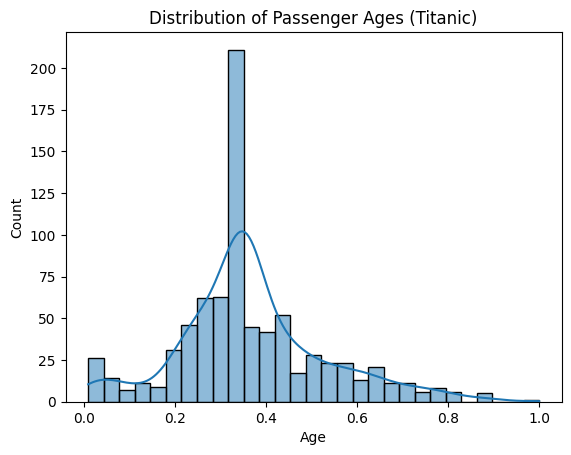

In [95]:
# Use Seaborn to plot the distribution of a numerical column
sns.histplot(data=df_real_world, x='Age', kde=True)

# Optional: Add a title
plt.title('Distribution of Passenger Ages (Titanic)')
plt.show()